# XGBoost Experiments
This notebook is a lightweight sandbox for primitive test runs using XGBoost.
Run cells in order from top to bottom.

In [41]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

BASE_DIR = "datasets_full.csv/datasets_full.csv"
USERS_FILE = "users.csv"

DATASETS = {
    "genuine_accounts.csv": 0,
    "fake_followers.csv": 1,
    "social_spambots_1.csv": 1,
    "social_spambots_2.csv": 1,
    "social_spambots_3.csv": 1,
    "traditional_spambots_1.csv": 1,
    "traditional_spambots_2.csv": 1,
    "traditional_spambots_3.csv": 1,
    "traditional_spambots_4.csv": 1,
}

USER_FEATURES = [
    "statuses_count", "followers_count", "friends_count",
    "favourites_count", "listed_count", "default_profile",
    "default_profile_image", "verified"
]

TWEET_FEATURES = [
   "text", "reply_count", "favorite_count", "num_urls", "num_mentions"
]

XGB_PARAMS = {
    "n_estimators": 300,
    "max_depth": 5,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "logloss",
    "use_label_encoder": False,
    "random_state": 42,
}

print("Dataset root:", BASE_DIR)
print("Files configured:", len(DATASETS))
print("XGBoost version:", xgb.__version__)

Dataset root: datasets_full.csv/datasets_full.csv
Files configured: 9
XGBoost version: 3.2.0


In [42]:
def resolve_users_csv(base_dir, dataset_entry):
    """Resolve dataset entry to a users.csv path."""
    candidates = [
        os.path.join(base_dir, dataset_entry),
        os.path.join(base_dir, dataset_entry, USERS_FILE),
        os.path.join(base_dir, dataset_entry, dataset_entry, USERS_FILE),
    ]
    for p in candidates:
        if os.path.isfile(p):
            return p
    return None


def load_all_data(dataset_map, base_dir):
    """Load all configured datasets and attach binary labels."""
    frames = []
    missing_files = []

    for dataset_entry, label in dataset_map.items():
        path = resolve_users_csv(base_dir, dataset_entry)
        if path is None:
            missing_files.append(dataset_entry)
            continue

        df = pd.read_csv(
            path,
            encoding="utf-8",
            on_bad_lines="skip",
            low_memory=False,
        )
        df["label"] = int(label)
        df["source_file"] = dataset_entry
        frames.append(df)
        print(f"Loaded {dataset_entry}: {len(df):,} rows")

    if missing_files:
        print("\nMissing dataset entries:")
        for p in missing_files:
            print("-", p)

    if not frames:
        raise ValueError("No dataset files were loaded. Check BASE_DIR and DATASETS.")

    all_data = pd.concat(frames, ignore_index=True)
    print(f"\nTotal rows loaded: {len(all_data):,}")
    return all_data


def load_tweets(base_dir, dataset_entry):
    """Load and aggregate tweet-level features per user."""
    candidates = [
        os.path.join(base_dir, dataset_entry, "tweets.csv"),
        os.path.join(base_dir, dataset_entry, dataset_entry, "tweets.csv"),
    ]

    for path in candidates:
        if os.path.isfile(path):
            available = ["user_id"] + TWEET_FEATURES
            chunks = []
            for chunk in pd.read_csv(
                path,
                usecols=lambda c: c in available,
                chunksize=100_000,
                encoding="utf-8",
                on_bad_lines="skip",
            ):
                chunks.append(chunk)

            dataframe = pd.concat(chunks, ignore_index=True)
            agg_cols = [c for c in TWEET_FEATURES if c in dataframe.columns]
            dataframe[agg_cols] = dataframe[agg_cols].apply(pd.to_numeric, errors="coerce")
            agg_cols = [c for c in agg_cols if pd.api.types.is_numeric_dtype(dataframe[c])]

            if not agg_cols:
                return None

            return dataframe.groupby("user_id")[agg_cols].mean().reset_index()

    return None

In [43]:
# Block 1: Data loading (full configured datasets)
raw = load_all_data(DATASETS, BASE_DIR)

tweet_aggs = []
for dataset_entry in DATASETS:
    agg = load_tweets(BASE_DIR, dataset_entry)
    if agg is not None:
        tweet_aggs.append(agg)

if tweet_aggs:
    all_tweets = pd.concat(tweet_aggs, ignore_index=True)
    if "id" in raw.columns:
        raw = raw.rename(columns={"id": "user_id"})
    raw = raw.merge(all_tweets, on="user_id", how="left")

print("Raw data shape:", raw.shape)

Loaded genuine_accounts.csv: 3,474 rows
Loaded fake_followers.csv: 3,351 rows
Loaded social_spambots_1.csv: 991 rows
Loaded social_spambots_2.csv: 3,457 rows
Loaded social_spambots_3.csv: 464 rows
Loaded traditional_spambots_1.csv: 1,000 rows
Loaded traditional_spambots_2.csv: 100 rows
Loaded traditional_spambots_3.csv: 403 rows
Loaded traditional_spambots_4.csv: 1,128 rows

Total rows loaded: 14,368
Raw data shape: (14368, 49)


In [44]:
# Block 2: Slicing and preprocessing
available_numeric = [c for c in USER_FEATURES if c in raw.columns]
if not available_numeric:
    raise ValueError("No numeric feature columns found in raw data.")

X = raw[available_numeric].copy()
X = X.apply(pd.to_numeric, errors="coerce")

tweet_features = [c for c in TWEET_FEATURES if c in raw.columns]
X = pd.concat([X, raw[tweet_features]], axis=1)
X = X.fillna(0)

print("Features:", list(X.columns))
print("Shape:", X.shape)

y = raw["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Class balance:\n", y.value_counts(dropna=False))
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

Features: ['statuses_count', 'followers_count', 'friends_count', 'favourites_count', 'listed_count', 'default_profile', 'default_profile_image', 'verified', 'text', 'reply_count', 'favorite_count', 'num_urls', 'num_mentions']
Shape: (14368, 13)
Train shape: (11494, 13)
Test shape: (2874, 13)
Class balance:
 label
1    10894
0     3474
Name: count, dtype: int64
scale_pos_weight: 0.3189


In [45]:
# Block 3: Training
model = xgb.XGBClassifier(
    **XGB_PARAMS,
    scale_pos_weight=scale_pos_weight,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)

print("\nTraining complete.")
if hasattr(model, 'best_iteration') and model.best_iteration is not None:
    print("Best iteration:", model.best_iteration)
else:
    print("No early stopping used. Total rounds:", model.n_estimators)

[0]	validation_0-logloss:0.60340
[50]	validation_0-logloss:0.02526
[100]	validation_0-logloss:0.01715
[150]	validation_0-logloss:0.01551


/Users/katherinesanders/Desktop/ML Project/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [11:36:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[200]	validation_0-logloss:0.01565
[250]	validation_0-logloss:0.01562
[299]	validation_0-logloss:0.01579

Training complete.
No early stopping used. Total rounds: 300


In [ ]:
# Block 4: Evaluation
pred = model.predict(X_test)
pred_proba = model.predict_proba(X_test)[:, 1]

print(f"accuracy:          {accuracy_score(y_test, pred):.4f}")
print(f"balanced_accuracy: {balanced_accuracy_score(y_test, pred):.4f}")
print(f"f1_macro:          {f1_score(y_test, pred, average='macro'):.4f}")
print(f"roc_auc:           {roc_auc_score(y_test, pred_proba):.4f}")
print(f"AUPRC:             {average_precision_score(y_test, pred_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))
print("\nClassification Report:")
print(classification_report(y_test, pred, digits=4))

importance_df = (
    pd.DataFrame(model.get_booster().get_score(importance_type="gain"), index=["gain"])
    .T.rename_axis("feature").reset_index()
    .sort_values("gain", ascending=False)
)

print("\nTop 10 features by gain:")
display(importance_df.head(10))

accuracy:          0.9955
balanced_accuracy: 0.9936
f1_macro:          0.9938
roc_auc:           0.9998
AUPRC:             0.9999

Confusion Matrix:
[[ 688    7]
 [   6 2173]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9914    0.9899    0.9906       695
           1     0.9968    0.9972    0.9970      2179

    accuracy                         0.9955      2874
   macro avg     0.9941    0.9936    0.9938      2874
weighted avg     0.9955    0.9955    0.9955      2874


Top 10 features by gain:


,feature,gain
7,reply_count,62.694515
3,favourites_count,55.796680
10,num_mentions,32.544872
9,num_urls,27.258564
8,favorite_count,7.710947
0,statuses_count,4.178838
4,listed_count,1.601138
2,friends_count,1.163528
6,default_profile_image,1.101699
1,followers_count,0.896130


In [ ]:
# Block 5: Feature importance list
importance = model.get_booster().get_score(importance_type="gain")
importance_sorted = sorted(importance.items(), key=lambda x: x[1], reverse=True)

print("Top 10 Features — XGBoost (gain):")
for i, (feature, score) in enumerate(importance_sorted[:10], 1):
    print(f"  {i:2}. {feature:<30} {score:.4f}")

Top 10 Features — XGBoost (gain):
   1. favourites_count               63.7930
   2. reply_count                    62.6945
   3. num_mentions                   32.5449
   4. num_urls                       27.2586
   5. favorite_count                 7.7109
   6. statuses_count                 4.7808
   7. listed_count                   1.7930
   8. friends_count                  1.3358
   9. default_profile_image          1.1017
  10. followers_count                1.0491


In [ ]:
# Block 6: Save model
MODEL_PATH = "xgboost_bot_detector.json"
model.save_model(MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to xgboost_bot_detector.json


/Users/katherinesanders/Desktop/ML Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


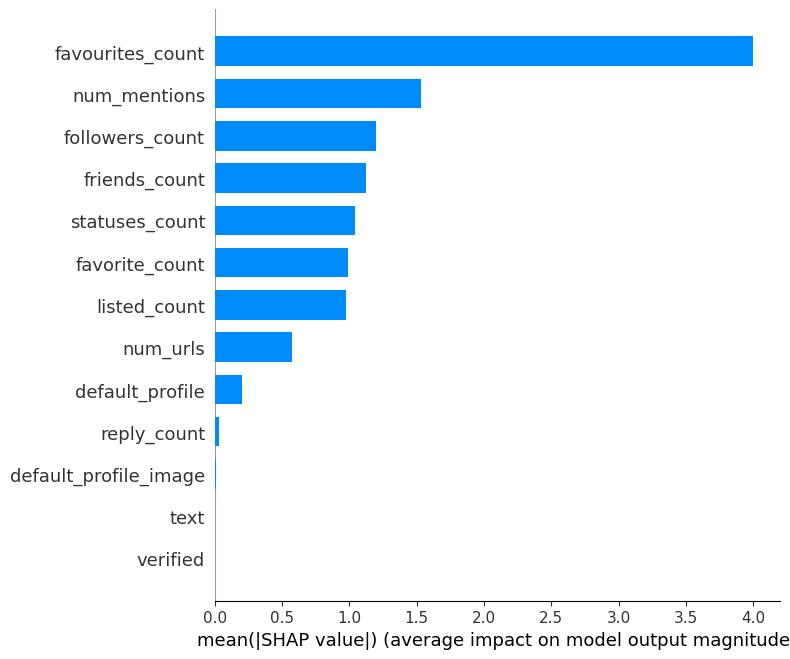

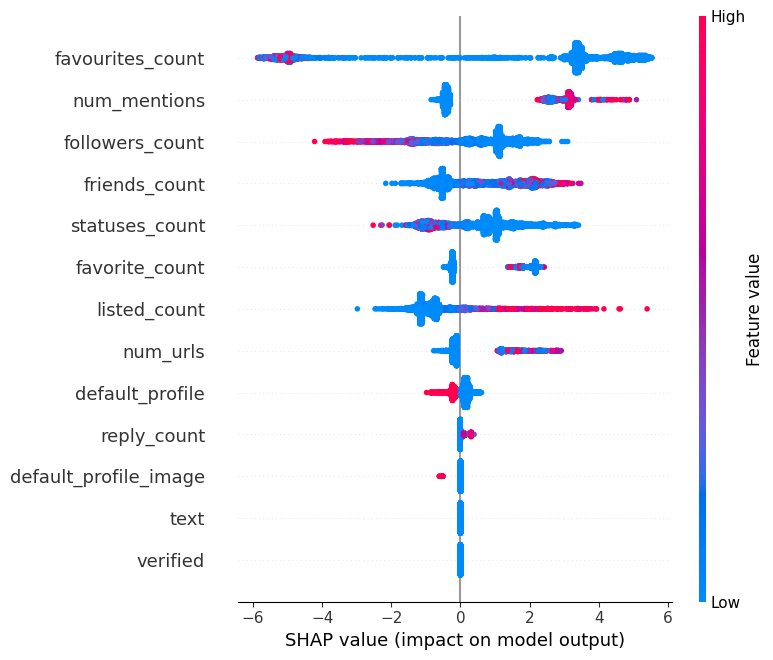

In [50]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar") 
shap.summary_plot(shap_values, X_test) 

## Run Order
1. Cell 1: imports and constants
2. Cell 2: helper functions
3. Cell 3: full data loading
4. Cell 4: slicing and preprocessing
5. Cell 5: training
6. Cell 6: evaluation
7. Cell 7: feature importance list
8. Cell 8: save model